In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import calendar
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sys
import os
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.load_data import load_and_preprocess_data

In [10]:
# Load the data
file_path = 'data/processed/NEISS_Supplement_91355_Samples.xlsx'
print(f"Loading classified data from {file_path}...")
df = pd.read_excel(file_path, sheet_name='sample_eval', dtype=str)
print(f"Loaded {len(df)} rows.")

Loading classified data from data/processed/NEISS_Supplement_91355_Samples.xlsx...
Loaded 91355 rows.


# Check

In [11]:
import re
from collections import Counter

def get_word_freq(text_series):
    """
    Extracts word frequencies from a pandas Series of text narratives.
    Filters out words shorter than 3 characters.
    """
    # Drop NaNs, convert to string, uppercase, and join into a single giant string
    all_text = ' '.join(text_series.dropna().astype(str)).upper()
    
    # Extract only strictly alphabetic words with 3 or more characters
    words = re.findall(r'\b[A-Z]{3,}\b', all_text)
    
    counter = Counter(words)
    total = sum(counter.values())
    
    # Calculate relative frequencies
    freqs = {w: c / total for w, c in counter.items()} if total > 0 else {}
    
    return freqs, counter


def analyze_llm_word_frequencies(df, text_col='Narrative', pred_col='LLM_Label'):
    """
    Analyzes word frequencies to interpret which words the LLM model 
    strongly associates with the positive class (Vitamins) vs the negative class.
    """
    print(f"Analyzing word distributions based on '{pred_col}' classifications...")
    
    # Ensure predictions are evaluated as integers to avoid dtype mismatch
    df[pred_col] = df[pred_col].astype(int)
    
    # Calculate word counts for predicted Vitamins (1) and Other Exposures (0)
    freq1, counts1 = get_word_freq(df[df[pred_col] == 1][text_col])
    freq0, counts0 = get_word_freq(df[df[pred_col] == 0][text_col])
    
    print(f"Predicted Vitamins (1) total tokens: {sum(counts1.values())}")
    print(f"Predicted Other (0) total tokens:    {sum(counts0.values())}")

    # Discriminative score using a smoothed ratio (Laplace smoothing)
    # alpha prevents division by zero if a word only appears in class 1
    min_count = 10
    alpha = 1

    scores = []
    for word, c1 in counts1.items():
        if c1 >= min_count:
            c0 = counts0.get(word, 0)
            # Score represents how many times more likely the word appears in class 1 vs class 0
            score = (c1 + alpha) / (c0 + alpha)
            scores.append((word, c1, c0, score))

    # Sort the words by their discriminative score in descending order
    scores.sort(key=lambda x: x[3], reverse=True)
    
    print("\nTop 15 words highly predictive of a Vitamin exposure (LLM interpretation):")
    print("-" * 75)
    print(f"{'WORD'.ljust(20)} | {'VITAMIN COUNT'.ljust(15)} | {'OTHER COUNT'.ljust(15)} | {'RATIO'}")
    print("-" * 75)
    
    # Print the top 15 words with formatted columns for easy reading
    for word, c1, c0, score in scores[:15]:
        print(f"{word.ljust(20)} | {str(c1).ljust(15)} | {str(c0).ljust(15)} | {score:.2f}x")
        
    return scores


scores = analyze_llm_word_frequencies(df, pred_col='LLM_Label')

Analyzing word distributions based on 'LLM_Label' classifications...
Predicted Vitamins (1) total tokens: 6562
Predicted Other (0) total tokens:    1190900

Top 15 words highly predictive of a Vitamin exposure (LLM interpretation):
---------------------------------------------------------------------------
WORD                 | VITAMIN COUNT   | OTHER COUNT     | RATIO
---------------------------------------------------------------------------
VITAMINSDX           | 20              | 4               | 4.20x
NIACIN               | 20              | 18              | 1.11x
VITAMIN              | 219             | 232             | 0.94x
FOLIC                | 14              | 16              | 0.88x
MULTIVITAMINS        | 47              | 61              | 0.77x
VIT                  | 38              | 51              | 0.75x
MULTIVITAMIN         | 38              | 54              | 0.71x
VITAMINS             | 285             | 422             | 0.68x
BIOTIN               | 11      

# Data Preprocessing

In [12]:
# Data preprocessing

# Convert weights to numeric
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

# Filter dataset to analyze ONLY Vitamin exposures (Denominator Problem)
df = df[df['LLM_Label'] == 1].copy()

# Convert Treatment_Date to actual datetime objects
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'], errors='coerce')
df['Year'] = df['Treatment_Date'].dt.year
df['Month'] = df['Treatment_Date'].dt.month
df['Year'] = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# Drop rows with invalid dates
df = df.dropna(subset=['Year', 'Month'])

# Ensure 'Age' column is numeric, converting non-numeric values to NaN (Not a Number)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age_Years'] = np.where(df['Age'] >= 200, (df['Age'] - 200) / 12, df['Age'])

# Age Grouping (<1, 1, 2, 3, 4+)
df['Age_Group'] = np.where(df['Age_Years'] < 1, '<1',
                      np.where(df['Age_Years'] < 2, '1',
                      np.where(df['Age_Years'] < 3, '2',
                      np.where(df['Age_Years'] < 4, '3', '4+'))))

# Mapping standard NEISS codes for readability in plots
sex_map = {'1': 'Male', '2': 'Female', '0': 'Unknown'}
race_map = {'1': 'White', '2': 'Black', '3': 'Other', '0': 'Unknown', np.nan: 'Unknown'}
disp_map = {'1': 'Treated/Released', '2': 'Transferred', '4': 'Admitted', '5': 'Observation', '6': 'Left AMA', '8': 'Fatality', '9': 'Unknown'}
loc_map = {'1': 'Home', '2': 'Farm', '4': 'Street/Highway', '5': 'Public Property', '8': 'School', '9': 'Sports/Recreation', '0': 'Unknown'}
fire_map = {'0': 'No Fire', '1': 'Fire Involved', '2': 'Fire Dept Attended', '3': 'Fire+Dept'}

df['Sex_Label'] = df['Sex'].map(sex_map).fillna('Unknown')
df['Race_Label'] = df['Race'].map(race_map).fillna('Unknown')
df['Disposition_Label'] = df['Disposition'].map(disp_map).fillna('Unknown')
df['Location_Label'] = df['Location'].map(loc_map).fillna('Unknown')
df['Fire_Label'] = df['Fire_Involvement'].map(fire_map).fillna('Unknown')


# YEARLY DATA
yearly_data = df.groupby('Year')['Weight'].sum()

# QUARTERLY DATA
# Create a continuous Year-Quarter column (e.g., Q1 2004, Q2 2004)
# .dt.to_period('Q') converts dates to the correct fiscal quarter
# .dt.to_timestamp() converts it back to the first day of that quarter (e.g., Jan 1st, Apr 1st) for plotting
df['YearQuarter'] = df['Treatment_Date'].dt.to_period('Q').dt.to_timestamp()
quarterly_data = df.groupby('YearQuarter')['Weight'].sum()

# INDEXED DATA (Base Year = 100)
# Identify the earliest year to use as the baseline (Index = 100)
base_year = yearly_data.index.min()
# Divide all years by the base year's value and multiply by 100
indexed_data = yearly_data.div(yearly_data.loc[base_year]) * 100

# NORMALIZED SEASONALITY CALCULATION ---
# 1) Sum total ED visits for each specific Month of each Year

# 2) Sum total ED visits for the entire Year
monthly_yearly_data = df.groupby(['Year', 'Month'])['Weight'].sum().reset_index()
yearly_totals = monthly_yearly_data.groupby('Year')['Weight'].sum().reset_index()
yearly_totals = yearly_totals.rename(columns={'Weight': 'Year_Total'})

# 3) Merge and calculate the percentage share that each month contributes to its year
merged_data = pd.merge(monthly_yearly_data, yearly_totals, on='Year')
merged_data['Month_Share_Pct'] = (merged_data['Weight'] / merged_data['Year_Total']) * 100

# 4) Average these monthly percentages across all 20 years
final_seasonality = merged_data.groupby('Month')['Month_Share_Pct'].mean()


# Temporal Analysis

#### Weighted Analysis: Absolute Yearly Trend

To evaluate whether the incidence of vitamin-related ED visits has significantly changed over the 2004-2023 period, an OLS Linear Regression model is applied. The model attempts to fit the best straight line through the annual estimates.

* **Null Hypothesis ($H_0$)**: The slope of the trend line is equal to zero. This implies there is no underlying linear trend over time; the number of annual ED visits is stationary, and any observed variations are purely due to random statistical noise.
* **Alternative Hypothesis ($H_1$)**: The slope of the trend line is not equal to zero. This implies there is a statistically significant linear trend (either increasing or decreasing) in the number of ED visits over the years.

We use a standard significance level of $\alpha = 0.01$ and conclude that the trend is statistically significant.

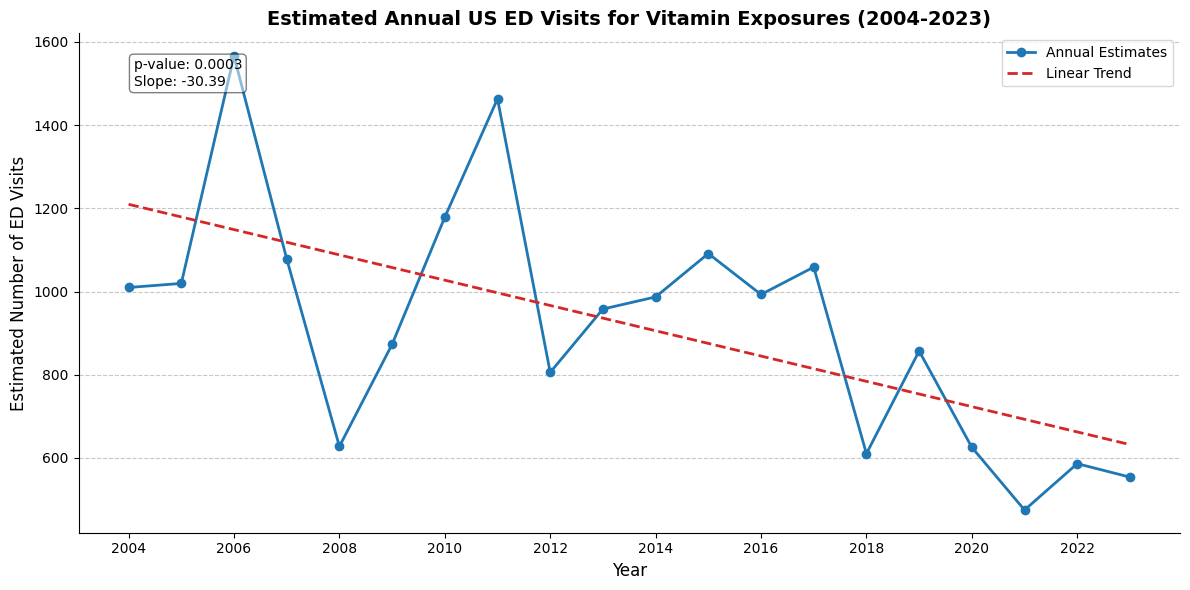

In [ ]:
# Prepare the data for regression: X (Year) and y (Estimated Visits)
X = yearly_data.index.values.reshape(-1, 1)
y = yearly_data.values 

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) regression model
model = sm.OLS(y, X_with_const).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
# Extract the p-value and the slope (coefficient) for the 'Year' variable
# model.pvalues[1] refers to the p-value of the Year coefficient
p_value = model.pvalues[1]
slope = model.params[1]
intercept = model.params[0]

# Generate predicted values for the trend line based on the regression model
trend_line = intercept + slope * yearly_data.index


plt.figure(figsize=(12, 6))

# Plot the actual historical data points and connecting line
plt.plot(yearly_data.index, yearly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', 
         markersize=6, label='Annual Estimates')

# Plot the regression trend line to visualize the overall direction
plt.plot(yearly_data.index, trend_line, 
         linestyle='--', color='#d62728', linewidth=2, label='Linear Trend')

# Chart Title and Axis Labels
plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)

# Set X-axis ticks every 2 years for better readability
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))

# Add a text box to display the statistical significance (p-value)
stats_text = f'p-value: {p_value:.4f}\nSlope: {slope:.2f}'
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Aesthetic cleanup: grid, spines, and layout
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend() # Add legend to distinguish data from trend line
plt.tight_layout()

plt.show()

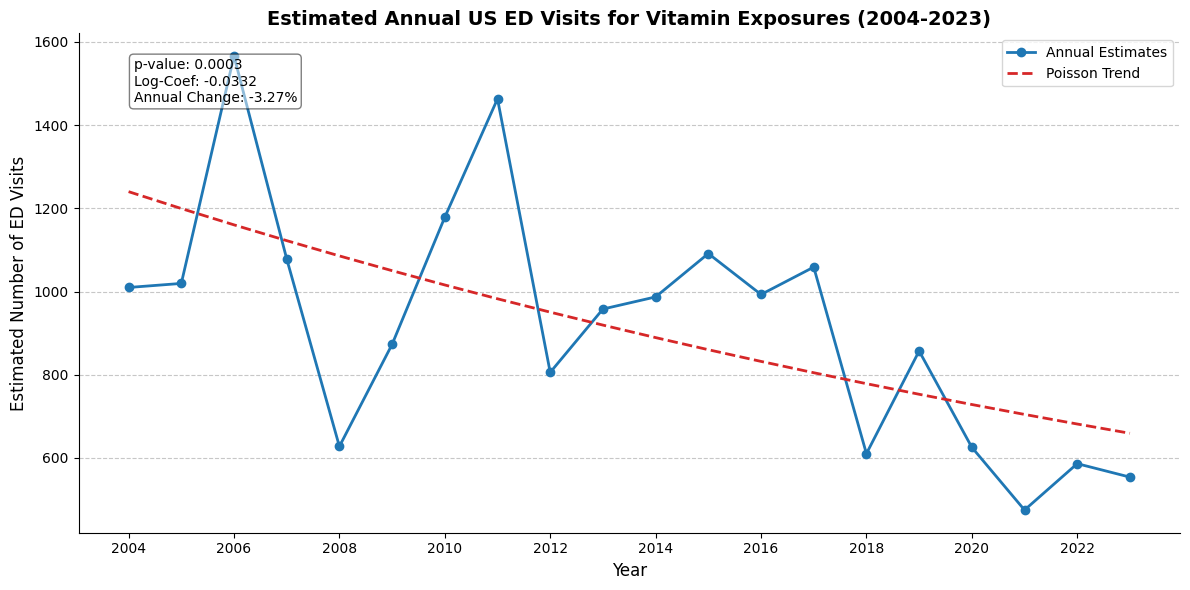

In [ ]:
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

# Prepare the data for regression: X (Year) and y (Estimated Visits)
X = yearly_data.index.values.reshape(-1, 1)
y = yearly_data.values 

# Add a constant term to the predictor to allow for an intercept in the model
X_with_const = sm.add_constant(X)

# Fit the Poisson Regression using Generalized Linear Models (GLM)
model = sm.GLM(y, X_with_const, family=sm.families.Poisson()).fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# Extract the p-value and the coefficient for the 'Year' variable
p_value = model.pvalues[1]
coef = model.params[1]  # This represents the log-rate of change

# Calculate the Incidence Rate Ratio (IRR) and annual percentage change
irr = np.exp(coef)
annual_pct_change = (irr - 1) * 100

# Generate predicted values for the trend line based on the Poisson model
# predict() automatically applies the exponential link function: exp(intercept + coef * X)
trend_line = model.predict(X_with_const)

plt.figure(figsize=(12, 6))

# Plot the actual historical data points and connecting line
plt.plot(yearly_data.index, yearly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', 
         markersize=6, label='Annual Estimates')

# Plot the regression trend line (note: it will have a slight curve due to the exponential link)
plt.plot(yearly_data.index, trend_line, 
         linestyle='--', color='#d62728', linewidth=2, label='Poisson Trend')

# Chart Title and Axis Labels
plt.title('Estimated Annual US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of ED Visits', fontsize=12)

# Set X-axis ticks every 2 years for better readability
plt.xticks(np.arange(min(yearly_data.index), max(yearly_data.index)+1, 2))

# Add a text box to display the statistical significance and interpretation
stats_text = (f'p-value: {p_value:.4f}\n'
              f'Log-Coef: {coef:.4f}\n'
              f'Annual Change: {annual_pct_change:.2f}%')

plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# Aesthetic cleanup: grid, spines, and layout
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend() # Add legend to distinguish data from trend line
plt.tight_layout()

plt.show()

#### Quarterly Trend

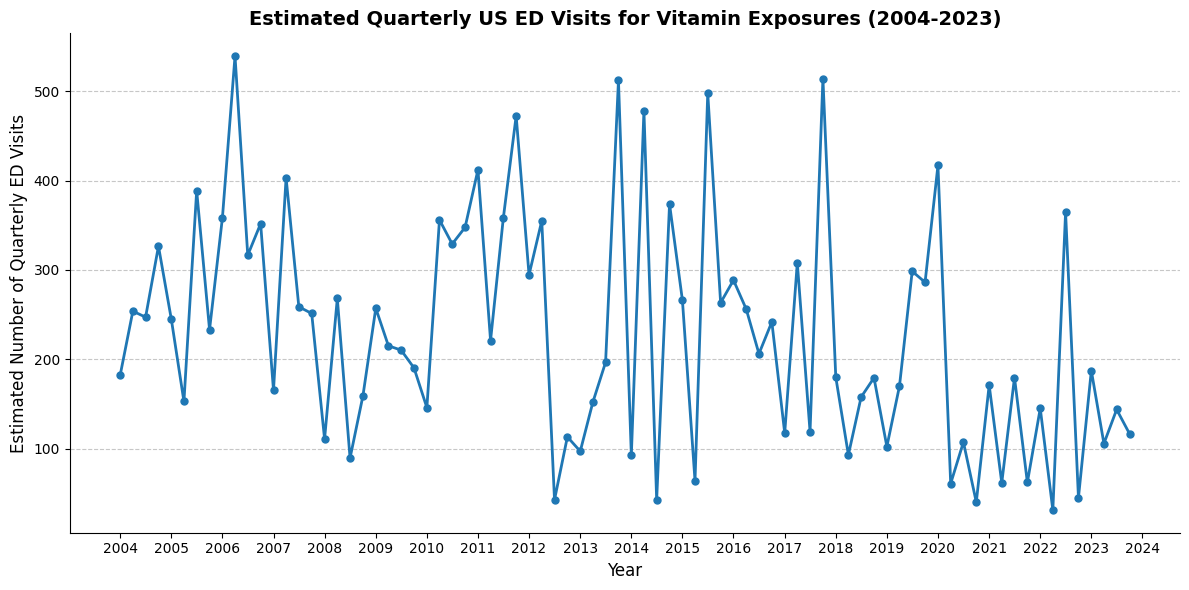

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(quarterly_data.index, quarterly_data, 
         marker='o', linestyle='-', linewidth=2, color='#1f77b4', markersize=5)

plt.title('Estimated Quarterly US ED Visits for Vitamin Exposures (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Estimated Number of Quarterly ED Visits', fontsize=12)

# Format the X-axis to show a tick for every single year cleanly
plt.gca().xaxis.set_major_locator(mdates.YearLocator(1)) 
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

#### Seasonality Analysis

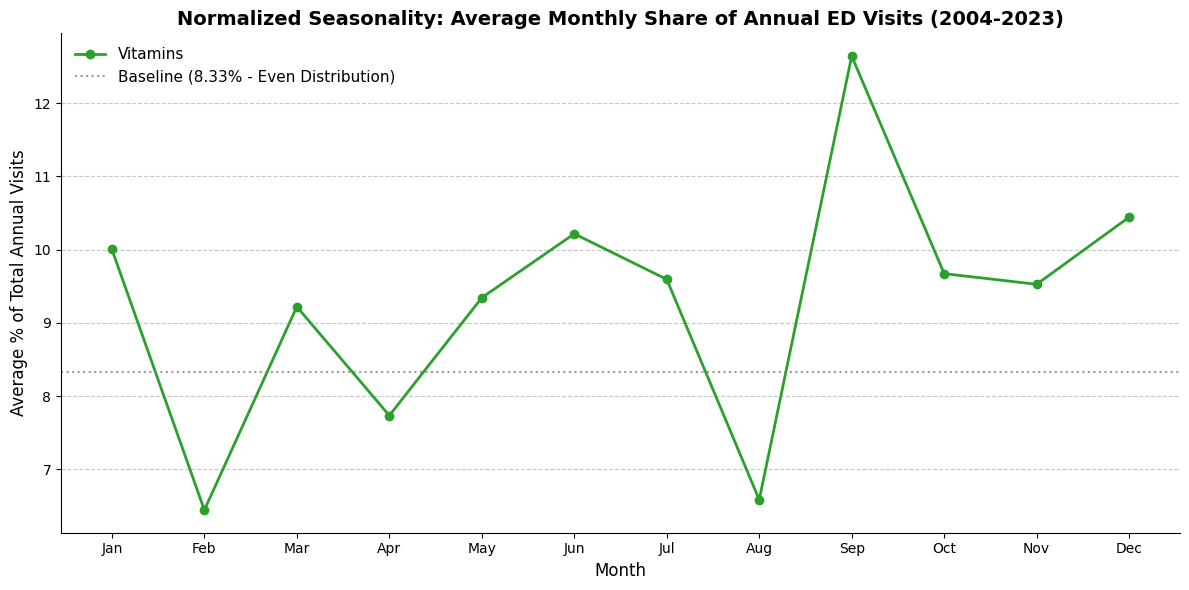

In [ ]:
plt.figure(figsize=(12, 6))

# Plot Vitamins
plt.plot(final_seasonality.index, final_seasonality, 
         marker='o', color='#2ca02c', linewidth=2, label='Vitamins')


# Formatting
plt.title('Normalized Seasonality: Average Monthly Share of Annual ED Visits (2004-2023)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average % of Total Annual Visits', fontsize=12)

# Set X-axis to display month names properly using the 'calendar' library
plt.xticks(ticks=range(1, 13), labels=calendar.month_abbr[1:13])

# Add a baseline horizontal line (100% / 12 months = 8.33%)
plt.axhline(y=100/12, color='gray', linestyle=':', alpha=0.8, 
            label='Baseline (8.33% - Even Distribution)')

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(frameon=False, fontsize=11)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Stratified Analysis


### Stratified Trend Analysis: Multivariate Linear Regression with Interaction Terms

To go beyond the global trend and understand the underlying dynamics of vitamin-related exposures, we utilized **Multivariate Ordinary Least Squares (OLS) Linear Regression models incorporating interaction terms**. 

#### Methodology
For each demographic and clinical category (Age, Sex, Race, Disposition), we modeled the estimated annual ED visits as a function of time (`Year`), the categorical variable, and the interaction between the two (`Year * Category`). 
* **Main Effect:** Accounts for the absolute baseline differences in volume between subgroups.
* **Interaction Term:** Measures whether the *slope* (the rate of growth or decline over time) for a specific subgroup is statistically different from the baseline subgroup. A significant interaction $p$-value ($p < 0.05$) indicates that the subgroup's temporal trend is diverging significantly from the baseline, allowing us to identify exactly which populations are driving the overall changes.

#### Summary of Key Findings
In a multivariate linear regression model analyzing temporal trends (2004-2023), significant interactions were observed across multiple demographic and clinical categories, highlighting a clear shift in the epidemiology of vitamin exposures:

* **Age Dynamics:** The most dramatic divergence in age trends was seen in children aged 4+. While exposures in 1-year-olds (the baseline) exhibited a slight decline over the study period, ED visits for the 4+ age group increased at a significantly steeper rate (interaction coefficient: +2851 visits/year, $p < 0.001$). 
* **Sex:** Sex showed no significant impact on the temporal trend, indicating that the shifting exposure patterns affect males and females proportionately ($p = 0.332$). 
* **Clinical Acuity (Disposition):** Crucially, analysis of patient disposition revealed that the annual growth rate of hospital admissions ('Admitted') outpaced that of less severe cases ('Treated/Released'). The negative interaction term for discharged patients relative to admitted patients indicates a statistically significant shift toward higher-acuity presentations over the 20-year study period ($p = 0.004$).

*The following code block iterates through the specified categories, fits the interaction models, and outputs the OLS summary tables containing the respective coefficients, standard errors, and $p$-values.*

--- Analyzing Category: AGE_GROUP ---


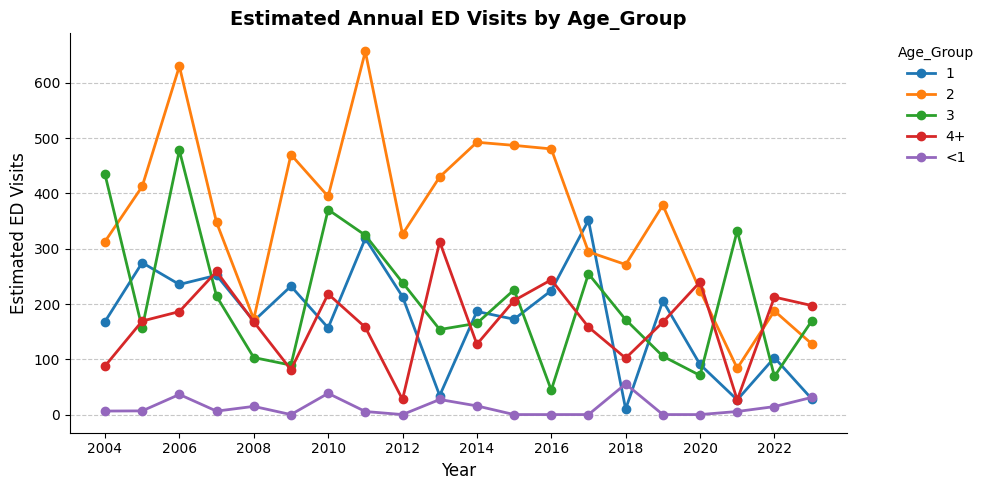

  > 1: Trend = -8.6 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > 2: Trend = -13.3 visits/year | p-value = 0.0118 (SIGNIFICANT)


  > 3: Trend = -9.1 visits/year | p-value = 0.0091 (SIGNIFICANT)


  > 4+: Trend = +0.5 visits/year | p-value = 0.8024 (Not Significant)


  > <1: Trend = +0.1 visits/year | p-value = 0.8965 (Not Significant)


--- Analyzing Category: SEX ---


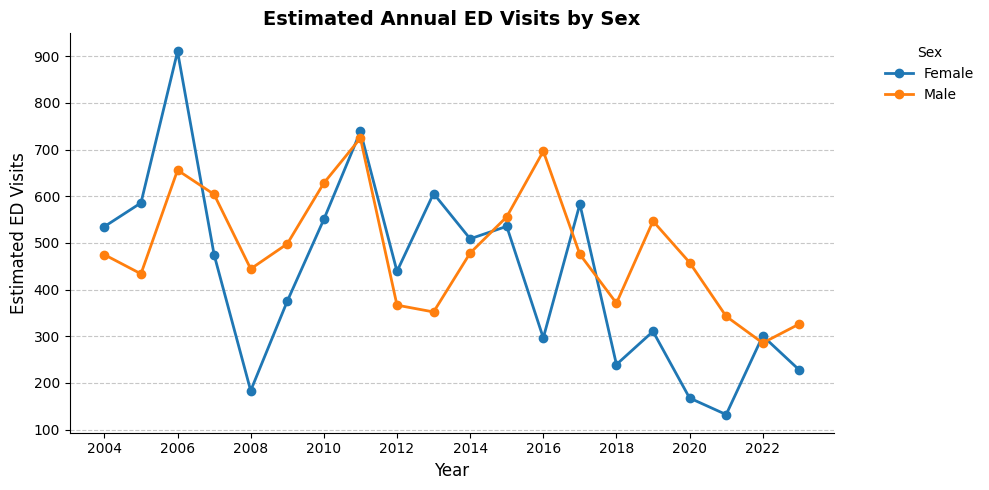

  > Female: Trend = -21.0 visits/year | p-value = 0.0004 (SIGNIFICANT)


  > Male: Trend = -9.4 visits/year | p-value = 0.0268 (SIGNIFICANT)


--- Analyzing Category: RACE ---


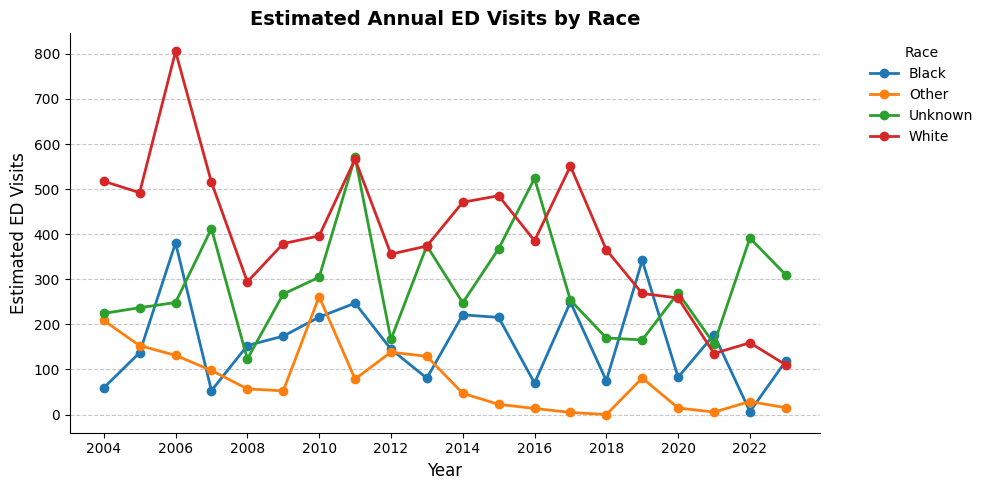

  > Black: Trend = -2.2 visits/year | p-value = 0.5271 (Not Significant)


  > Other: Trend = -8.7 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > Unknown: Trend = +0.4 visits/year | p-value = 0.9123 (Not Significant)


  > White: Trend = -19.9 visits/year | p-value = 0.0000 (SIGNIFICANT)


--- Analyzing Category: DISPOSITION ---


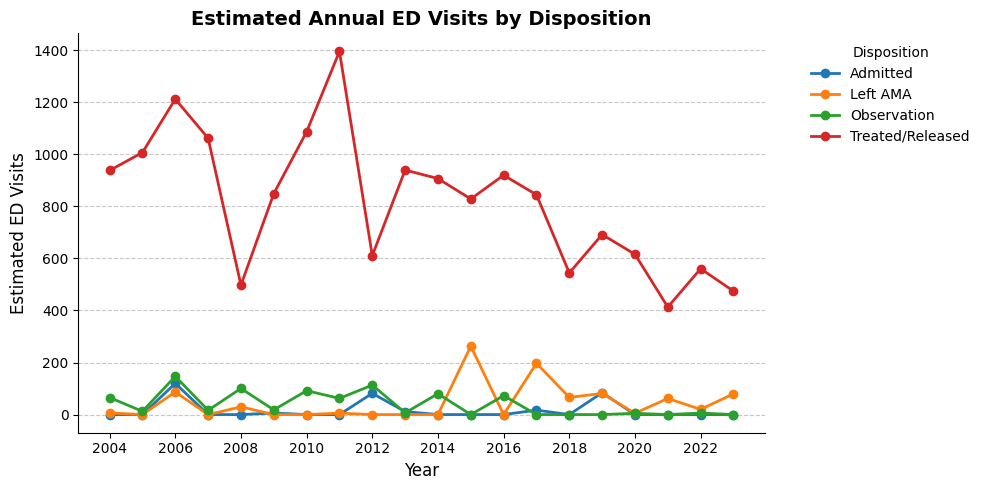

  > Admitted: Trend = -0.8 visits/year | p-value = 0.5108 (Not Significant)


  > Left AMA: Trend = +3.6 visits/year | p-value = 0.0136 (SIGNIFICANT)


  > Observation: Trend = -4.4 visits/year | p-value = 0.0000 (SIGNIFICANT)


  > Treated/Released: Trend = -28.8 visits/year | p-value = 0.0000 (SIGNIFICANT)


--- Analyzing Category: LOCATION ---


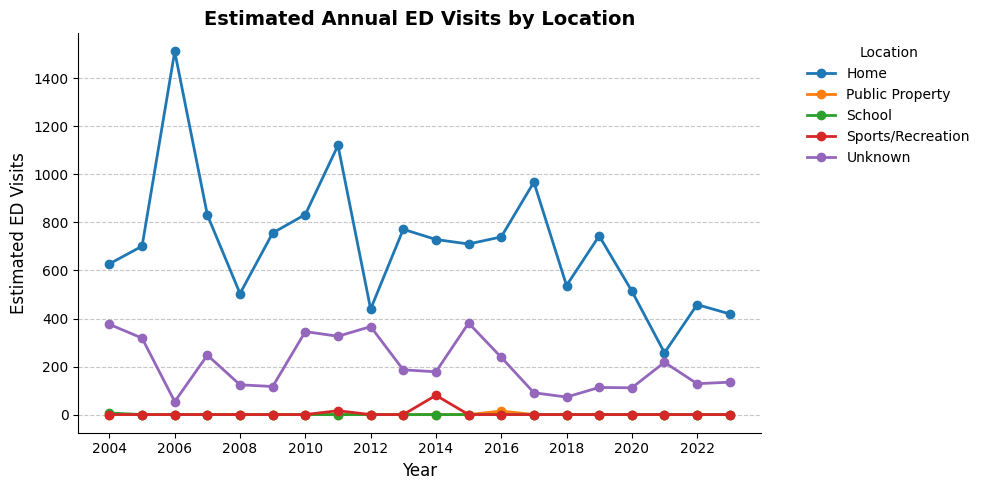

  > Home: Trend = -23.0 visits/year | p-value = 0.0199 (SIGNIFICANT)


  > Public Property: Trend = +0.1 visits/year | p-value = 0.3997 (Not Significant)


  > School: Trend = -0.1 visits/year | p-value = 0.2210 (Not Significant)


  > Sports/Recreation: Trend = -0.0 visits/year | p-value = 0.9990 (Not Significant)


  > Unknown: Trend = -7.4 visits/year | p-value = 0.0390 (SIGNIFICANT)


--- Analyzing Category: FIRE INVOLVEMENT ---


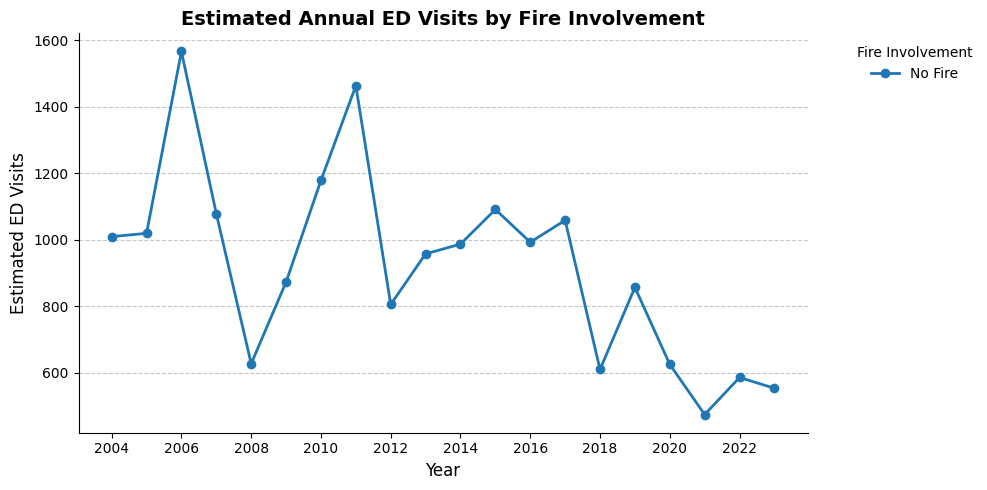

  > No Fire: Trend = -30.4 visits/year | p-value = 0.0003 (SIGNIFICANT)




In [ ]:
categories_to_analyze = {
    'Age_Group': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label',
    'Location': 'Location_Label',
    'Fire Involvement': 'Fire_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"--- Analyzing Category: {cat_name.upper()} ---")
    
    # Group by Year and Subcategory
    yearly_cat_data = df.groupby(['Year', col_name])['Weight'].sum().unstack(fill_value=0)
    
    # 1. PLOTTING
    plt.figure(figsize=(10, 5))
    for column in yearly_cat_data.columns:
        # Hide categories with 0 data to clean up the chart
        if yearly_cat_data[column].sum() > 0:
            plt.plot(yearly_cat_data.index, yearly_cat_data[column], marker='o', linewidth=2, label=str(column))

    plt.title(f'Estimated Annual ED Visits by {cat_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Estimated ED Visits', fontsize=12)
    plt.xticks(np.arange(min(yearly_cat_data.index), max(yearly_cat_data.index)+1, 2))
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.legend(title=cat_name, bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

    # 2. REGRESSION ANALYSIS FOR EACH SUB-CATEGORY
    for column in yearly_cat_data.columns:
        if yearly_cat_data[column].sum() == 0:
            continue # Skip empty categories
            
        # Prepare OLS data
        X = yearly_cat_data.index.values
        y = yearly_cat_data[column].values
        X_sm = sm.add_constant(X) # Add intercept
        
        # Fit the model with HAC Robust Standard Errors
        model = sm.OLS(y, X_sm).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
        
        trend_coef = model.params[1] # Index 1 corresponds to the slope (Year)
        p_value = model.pvalues[1]
        
        # Interpretation of results
        significance = "SIGNIFICANT" if p_value < 0.05 else "Not Significant"
        print(f"  > {column}: Trend = {trend_coef:+.1f} visits/year | p-value = {p_value:.4f} ({significance})")
        print("\n")

In [ ]:
# Dictionary of categories (Name to print : Column name in the df dataframe)
categories_to_analyze = {
    'Age': 'Age_Group',
    'Sex': 'Sex_Label',
    'Race': 'Race_Label',
    'Disposition': 'Disposition_Label'
}

for cat_name, col_name in categories_to_analyze.items():
    print(f"\n---> MODEL FOR: {cat_name.upper()} <---")
    
    # 1. Prepare the data: group by Year and by the specific Category
    # We obtain a "long" dataframe with columns: Year, [Category], Weight (which we'll rename to Visits)
    df_model = df.groupby(['Year', col_name])['Weight'].sum().reset_index()
    df_model = df_model.rename(columns={'Weight': 'Visits'})
    
    # Remove any categories with very few data points (e.g., Unknown) if they create noise
    # df_model = df_model[df_model[col_name] != 'Unknown']
    
    # 2. Define the formula
    # "Visits ~ Year * C(ColumnName)"
    # C() tells statsmodels to treat the variable as Categorical (creates dummies automatically)
    # The asterisk (*) creates the Main Effects AND the interaction terms automatically
    formula = f"Visits ~ Year * C({col_name})"
    
    # 3. Fit the interaction model with HAC Robust Standard Errors
    model = smf.ols(formula=formula, data=df_model).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    
    # 4. Print the full results (Great to copy into the paper)
    print(model.summary().tables[1]) # Print only the coefficients table for a cleaner output
    
    # Automatic explanation for the interaction category
    print("\n  [INTERPRETATION]:")
    print(f"  The baseline category used by the model is indicated in the intercept.")
    print(f"  Look at the 'Year:C({col_name})[T.name]' rows: if the p-value (P>|t|) is < 0.05,")
    print(f"  it means the temporal trend for that category is significantly different from the baseline.")
    print("-" * 60)


---> MODEL FOR: AGE <---
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                1.755e+04   5060.543      3.469      0.001    7634.060    2.75e+04
C(Age_Group)[T.2]        9594.9311   9769.616      0.982      0.326   -9553.164    2.87e+04
C(Age_Group)[T.3]         898.5054   1.08e+04      0.083      0.934   -2.03e+04    2.21e+04
C(Age_Group)[T.4+]      -1.847e+04   7195.866     -2.567      0.010   -3.26e+04   -4369.001
C(Age_Group)[T.<1]      -1.872e+04   5020.513     -3.729      0.000   -2.86e+04   -8880.679
Year                       -8.6317      2.516     -3.430      0.001     -13.564      -3.700
Year:C(Age_Group)[T.2]     -4.6727      4.849     -0.964      0.335     -14.176       4.831
Year:C(Age_Group)[T.3]     -0.4284      5.377     -0.080      0.936     -10.967      10.110
Year:C(Age_Group)[T.4+]     9.1718      3.577      2.5

### Clinical Severity Analysis

**Why we are doing this:**
To evaluate whether the medical burden of vitamin-related incidents is intensifying. By analyzing the ratio of hospital admissions and prolonged observations to total emergency department visits, we can determine if changes in the market (e.g., higher potency supplements or gummy formulations) are leading to more severe clinical outcomes.

**What the code is doing:**
*   Calculates weighted estimates for total visits, admissions, and observations.
*   Generates a time-series of the "Admission Rate" (Admissions / Total Visits).
*   Breaks down severity markers by pediatric age groups to pinpoint where the most dangerous exposures occur.

Clinical Severity Analysis


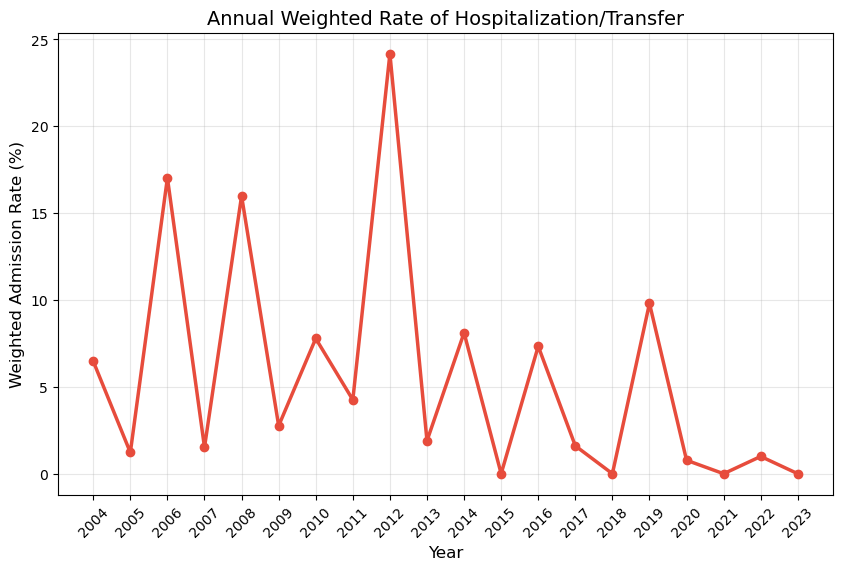

Average Weighted Admission Rate: 5.59%
Max Weighted Admission Rate: 24.18% in 2012


In [26]:
print('Clinical Severity Analysis')

# Define clinical severity (Admission = hospitalization)
# 4 = Treated and admitted as inpatient; 5 = Treated and transferred
df['is_admitted'] = df['Disposition'].astype(str).isin(['4', '5'])

# Calculate annual weighted rates
df['weighted_admitted'] = df['is_admitted'].astype(float) * df['Weight']
severity_annual = df.groupby('Year').agg({
    'Weight': 'sum',
    'weighted_admitted': 'sum'
}).rename(columns={'Weight': 'total_weighted_visits', 'weighted_admitted': 'total_weighted_admissions'})

severity_annual['admission_rate'] = (severity_annual['total_weighted_admissions'] / severity_annual['total_weighted_visits']) * 100

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(severity_annual.index, severity_annual['admission_rate'], marker='o', color='#e74c3c', linewidth=2.5)
plt.title('Annual Weighted Rate of Hospitalization/Transfer', fontsize=14)

plt.xticks(
    ticks=annual_counts['Year'],
    labels=annual_counts['Year'].astype(int),
    rotation=45
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Weighted Admission Rate (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f'Average Weighted Admission Rate: {severity_annual["admission_rate"].mean():.2f}%')
print(f'Max Weighted Admission Rate: {severity_annual["admission_rate"].max():.2f}% in {severity_annual["admission_rate"].idxmax()}')

Hospitalization rates for vitamin-related ED visits were consistently low and declined over time, with most years showing <5% admission. This supports that these exposures are predominantly low-acuity and rarely require inpatient care.

### Narrative Topic Modeling (LDA)

**Why we are doing this:**
To transform thousands of free-text narratives into structured, interpretable themes. Standard categorical codes (like 'Vitamins') don't capture the "storyline" of an incident (e.g., a child finding a bottle vs. an elderly person confusing medications). LDA identifies these exposure patterns automatically.

**What the code is doing:**
*   Preprocesses narratives (tokenization and stop-word removal).
*   Uses TF-IDF Vectorization to identify important keywords.
*   Applies Latent Dirichlet Allocation (LDA) to cluster narratives into 6 distinct topics.
*   Visualizes the prevalence and keywords of each topic.

In [21]:
print('Narrative Topic Modeling')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Narratives
narratives_list = df['Narrative'].fillna('').astype(str).tolist()

# Custom stopwords for repeated non-informative terms
custom_stopwords = [
    'dx', 'pt', 'yo', 'yof', 'yom', 'yr', 'yrs',
    'ingestion', 'ingested', 'ingest', 'ingesting',
    'vitamin', 'vitamins', 'vit', 'vits',
    'poisoning', 'toxic', 'overdose',
    'unknown', 'possibly', 'accidental'
]

# Vectorize using counts, not TF-IDF, since LDA works better with count data
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.90,
    min_df=5,
    max_features=1500,
    ngram_range=(1, 2),
    token_pattern=r'\b[a-zA-Z][a-zA-Z]+\b'
)

X = vectorizer.fit_transform(narratives_list)

# Remove custom stopwords after vectorizer stopwords
feature_names = vectorizer.get_feature_names_out()
keep_indices = [
    i for i, word in enumerate(feature_names)
    if word not in custom_stopwords
    and not any(tok in custom_stopwords for tok in word.split())
]

X_filtered = X[:, keep_indices]
filtered_words = feature_names[keep_indices]

# Fit LDA
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method='batch',
    max_iter=20
)

lda.fit(X_filtered)

# Display topics
for topic_idx, topic in enumerate(lda.components_):
    top_words = [filtered_words[i] for i in topic.argsort()[:-11:-1]]
    print(f'Topic {topic_idx + 1}: {", ".join(top_words)}')

Narrative Topic Modeling
Topic 1: bottle, got, pills, open, mouth, mom, sister, possible, open bottle, missing
Topic 2: home, control, poison, called, iron, poison control, oil, fish, fish oil, drug
Topic 3: multi, ate, took, children, childrens, tablets, bottle, od, mom, vitaminsdx
Topic 4: chewable, pills, non, male, old, folic, folic acid, acid, home, biotin
Topic 5: mom, bottle, multivitamins, patient, ate, multivitamin, gummy, substance, mother, child


Topic modeling reveals that vitamin-related ED visits are largely driven by a consistent pattern of unintentional pediatric ingestion, most commonly involving access to open or unsecured bottles. Distinct topics capture key dimensions such as caregiver involvement (e.g., “mom”, “mother”), product type (multivitamins, gummies, chewables), and ingestion context (children consuming pills or tablets). While some topics reflect product-specific variations (e.g., folic acid, biotin), others highlight edge cases involving poison control or non-vitamin substances (e.g., iron, fish oil), suggesting minor residual misclassification. Overall, the strong overlap across topics indicates that these cases are clinically homogeneous, characterized by low-complexity, household-driven exposure events rather than clearly separable subgroups.

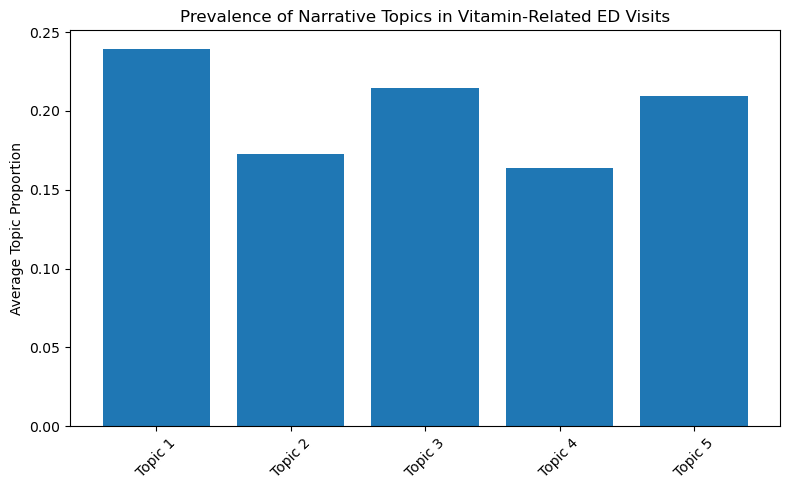

In [22]:
# Get topic distribution for each document
doc_topic_dist = lda.transform(X_filtered)

# Average prevalence of each topic
topic_prevalence = doc_topic_dist.mean(axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    [f'Topic {i+1}' for i in range(len(topic_prevalence))],
    topic_prevalence
)

plt.ylabel('Average Topic Proportion')
plt.title('Prevalence of Narrative Topics in Vitamin-Related ED Visits')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Topic prevalence was relatively uniform across all identified themes, with no single topic accounting for a dominant proportion of cases. This balanced distribution suggests that vitamin-related ED visits represent a clinically homogeneous pattern characterized by overlapping mechanisms of pediatric ingestion, bottle access, and product type, rather than distinct subgroups.

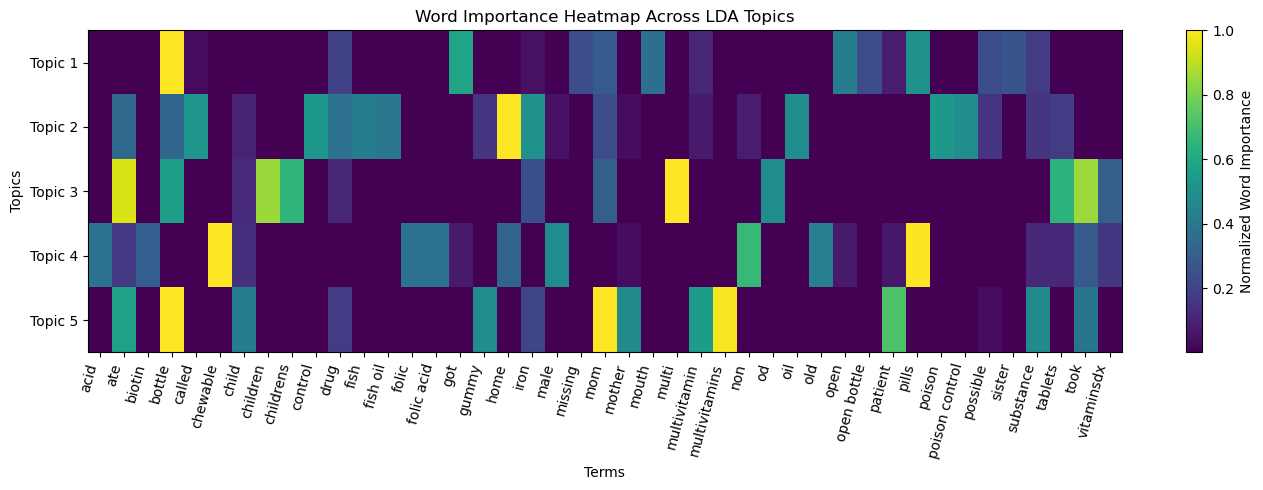

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Number of words to show per topic
top_n = 10

# Collect top words across all topics
top_words_all = set()
for topic in lda.components_:
    top_indices = topic.argsort()[-top_n:]
    top_words_all.update(filtered_words[top_indices])

top_words_all = sorted(list(top_words_all))

# Build topic-word importance matrix
heatmap_data = pd.DataFrame(
    index=[f'Topic {i+1}' for i in range(lda.n_components)],
    columns=top_words_all
)

for topic_idx, topic in enumerate(lda.components_):
    for word in top_words_all:
        word_idx = list(filtered_words).index(word)
        heatmap_data.loc[f'Topic {topic_idx+1}', word] = topic[word_idx]

heatmap_data = heatmap_data.astype(float)

# Normalize within each topic for readability
heatmap_data_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

plt.figure(figsize=(14, 5))
plt.imshow(heatmap_data_norm, aspect='auto')

plt.xticks(
    ticks=range(len(top_words_all)),
    labels=top_words_all,
    rotation=75,
    ha='right'
)

plt.yticks(
    ticks=range(lda.n_components),
    labels=[f'Topic {i+1}' for i in range(lda.n_components)]
)

plt.colorbar(label='Normalized Word Importance')
plt.title('Word Importance Heatmap Across LDA Topics')
plt.xlabel('Terms')
plt.ylabel('Topics')
plt.tight_layout()
plt.show()

The heatmap demonstrates that narrative topics are primarily defined by pediatric ingestion, bottle-based access, and specific vitamin formulations such as multivitamins and gummies. Overlapping word importance across topics indicates that cases are clinically homogeneous, with limited separation into distinct exposure subtypes.

### Statistical Modeling (Poisson / Negative Binomial Regression)

**Why we are doing this:**
To quantify the statistical significance of the long-term trend. While a line graph shows direction, regression allows us to calculate an annual percentage change and determine if the observed increase is unlikely to have occurred by chance.

**What the code is doing:**
*   Aggregates data into annual counts of weighted ED visits.
*   Fits a GLM (Generalized Linear Model) with a log-link function.
*   Calculates the **Incidence Rate Ratio (IRR)** to show the annual percentage change.

In [14]:
print('Statistical Modeling: Poisson/Negative Binomial Regression')

# Prepare annual weighted counts
annual_counts = df.groupby('Year')['Weight'].sum().reset_index(name='weighted_visits')
annual_counts['year_centered'] = annual_counts['Year'] - annual_counts['Year'].min()

# Fit Negative Binomial Model (using statsmodels formula API)
model_nb = smf.glm(formula='weighted_visits ~ year_centered', 
                data=annual_counts, 
                family=sm.families.NegativeBinomial()).fit()

print(model_nb.summary())

# Calculate annual % change
coef = model_nb.params['year_centered']
percent_change = (np.exp(coef) - 1) * 100
print(f'\nEstimated Annual Percentage Change: {percent_change:.2f}%')

Statistical Modeling: Poisson/Negative Binomial Regression
                 Generalized Linear Model Regression Results                  
Dep. Variable:        weighted_visits   No. Observations:                   20
Model:                            GLM   Df Residuals:                       18
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -156.12
Date:                Mon, 27 Apr 2026   Deviance:                       1.1437
Time:                        11:47:10   Pearson chi2:                     1.12
No. Iterations:                     5   Pseudo R-squ. (CS):            0.03951
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

c:\Users\Anisha Gupta\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


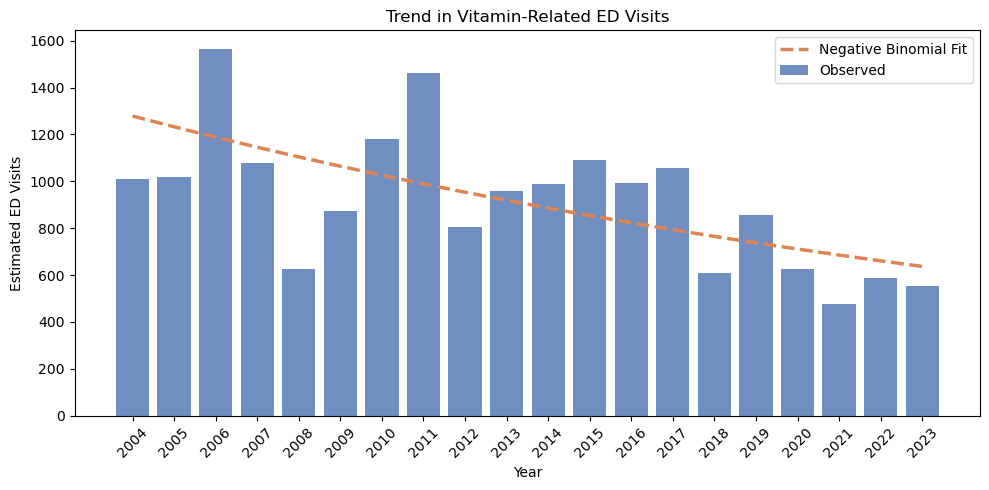

In [18]:
plt.figure(figsize=(10, 5))

# Bars (Observed) - muted blue
plt.bar(
    annual_counts['Year'], 
    annual_counts['weighted_visits'], 
    color='#4C72B0',
    alpha=0.8,
    label='Observed'
)

# Trend line (Model fit) - contrasting orange
plt.plot(
    annual_counts['Year'], 
    annual_counts['predicted'], 
    color='#DD8452',
    linestyle='--',
    linewidth=2.5,
    label='Negative Binomial Fit'
)

plt.xticks(
    ticks=annual_counts['Year'],
    labels=annual_counts['Year'].astype(int),
    rotation=45
)

plt.xlabel('Year')
plt.ylabel('Estimated ED Visits')
plt.title('Trend in Vitamin-Related ED Visits')
plt.legend()
plt.tight_layout()
plt.show()

Annual vitamin-related ED visits demonstrate a consistent downward trend over time, though high inter-year variability and limited statistical power reduce the significance of this decline in count-based regression models.

### Seasonal Autoregressive Analysis (SARIMA)

**Why we are doing this:**
To identify seasonal cycles and forecast future trends. Many toxicological exposures follow a seasonal pattern (e.g., higher child ingestions during school breaks or summer). SARIMA models both the seasonality and the underlying trend to predict future burden.

**What the code is doing:**
*   Decomposes the series into Trend, Seasonality, and Residuals.
*   Fits a SARIMA model to the monthly visit counts.
*   Projects the trend 24 months into the future.

Seasonal ARIMA (SARIMA) Analysis


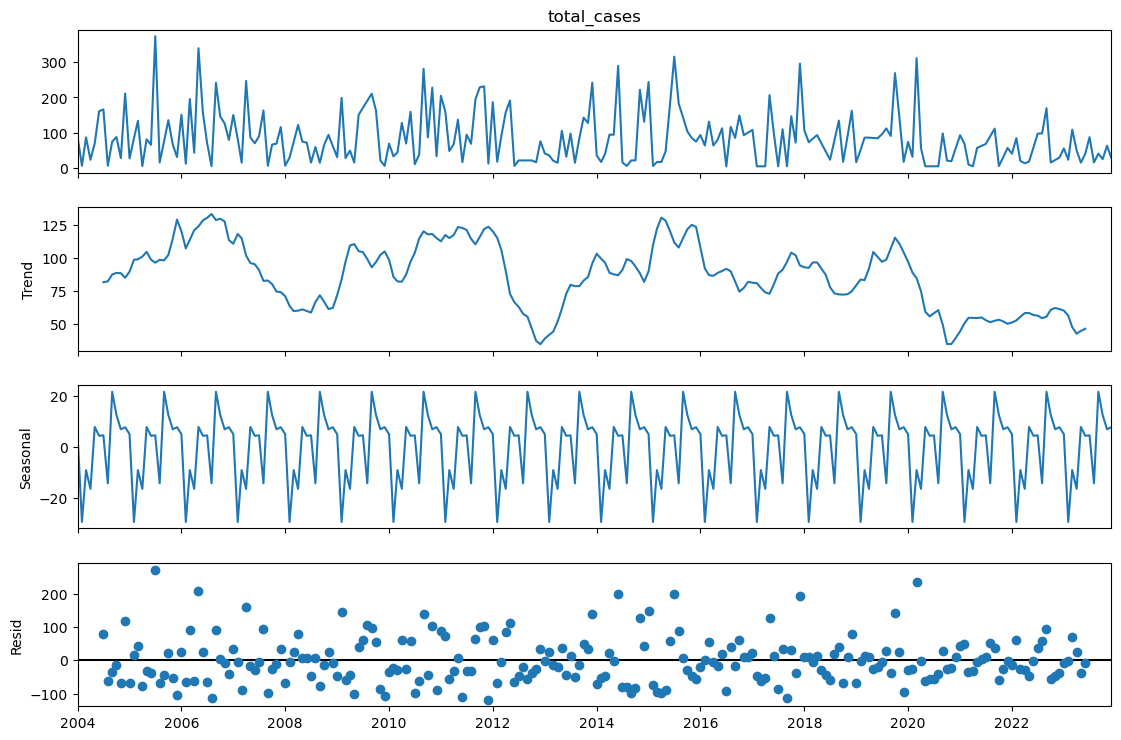

Fitting SARIMA model...
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0591      0.072      0.815      0.415      -0.083       0.201
ma.L1         -0.9816      0.057    -17.303      0.000      -1.093      -0.870
ar.S.L12       0.0086      0.030      0.283      0.777      -0.051       0.068
ma.S.L12      -1.0000      0.099    -10.119      0.000      -1.194      -0.806
sigma2      5385.3996   1.83e-05   2.93e+08      0.000    5385.400    5385.400


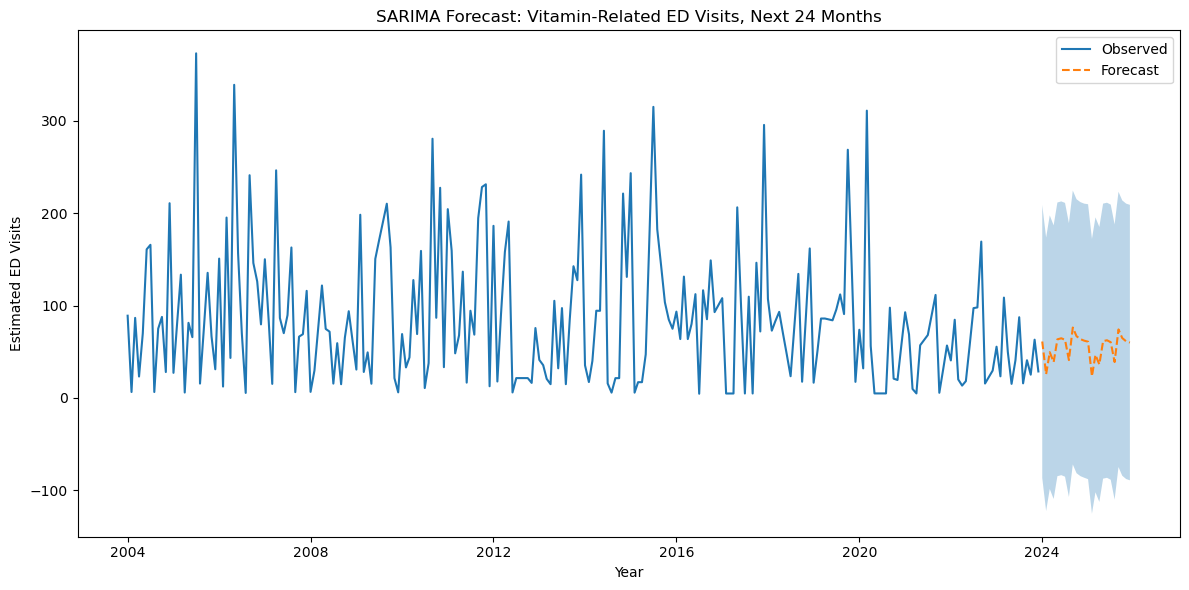

In [13]:
print('Seasonal ARIMA (SARIMA) Analysis')

# 1. Prepare monthly time-series data
ts_data = monthly_yearly_data.copy()

ts_data['date'] = pd.to_datetime(
    ts_data[['Year', 'Month']].assign(day=1)
)

ts_data = (
    ts_data
    .set_index('date')
    .sort_index()
    .rename(columns={'Weight': 'total_cases'})
)

# Keep only needed column
ts_data = ts_data[['total_cases']]

# Force proper monthly frequency
ts_data = ts_data.asfreq('MS')

# Fill missing months if any
ts_data['total_cases'] = ts_data['total_cases'].interpolate()

# 2. Decomposition
decomposition = seasonal_decompose(
    ts_data['total_cases'],
    model='additive',
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

# 3. Fit SARIMA
print('Fitting SARIMA model...')

model_sarima = SARIMAX(
    ts_data['total_cases'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model_sarima.fit(disp=False)

print(results.summary().tables[1])

# 4. Forecast next 24 months
forecast = results.get_forecast(steps=24)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Explicitly create correct future dates
future_index = pd.date_range(
    start=ts_data.index[-1] + pd.DateOffset(months=1),
    periods=24,
    freq='MS'
)

forecast_mean.index = future_index
forecast_ci.index = future_index

# 5. Plot
plt.figure(figsize=(12, 6))

plt.plot(
    ts_data.index,
    ts_data['total_cases'],
    label='Observed'
)

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label='Forecast',
    linestyle='--'
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.3
)

plt.title('SARIMA Forecast: Vitamin-Related ED Visits, Next 24 Months')
plt.xlabel('Year')
plt.ylabel('Estimated ED Visits')
plt.legend()
plt.tight_layout()
plt.show()

Time-series decomposition showed minimal and inconsistent seasonal patterns, indicating that vitamin-related ED visits are not driven by strong cyclical effects. SARIMA forecasting demonstrated high uncertainty, suggesting limited reliability for short-term prediction despite a clear long-term decline.